In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense
from keras_tuner import RandomSearch
from keras.optimizers import Adam
import matplotlib.pyplot as plt
import seaborn as sns

ModuleNotFoundError: No module named 'pandas'

In [ ]:
#load dataset
data=pd.read_csv("Real_Combine.csv")
data.head()

NameError: name 'pd' is not defined

In [ ]:
data.columns

Index(['T', 'TM', 'Tm', 'SLP', 'H', 'VV', 'V', 'VM', 'PM 2.5'], dtype='object')

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1093 entries, 0 to 1092
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   T       1093 non-null   float64
 1   TM      1093 non-null   float64
 2   Tm      1093 non-null   float64
 3   SLP     1093 non-null   float64
 4   H       1093 non-null   float64
 5   VV      1093 non-null   float64
 6   V       1093 non-null   float64
 7   VM      1093 non-null   float64
 8   PM 2.5  1092 non-null   float64
dtypes: float64(9)
memory usage: 77.0 KB


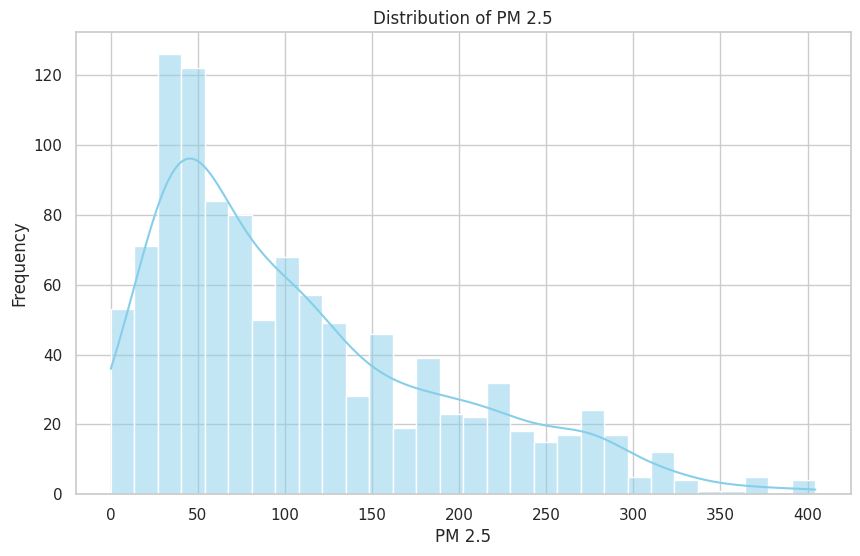

In [ ]:
#histogram
plt.figure(figsize=(10, 6))
sns.histplot(data['PM 2.5'], kde=True, color='skyblue', bins=30)
plt.title('Distribution of PM 2.5')
plt.xlabel('PM 2.5')
plt.ylabel('Frequency')
plt.show()

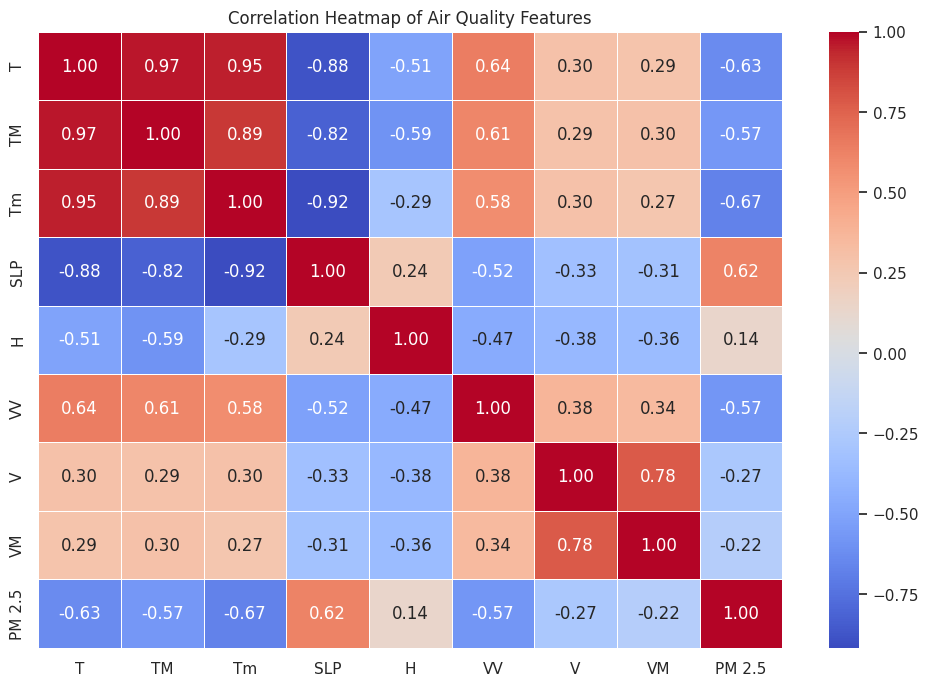

In [ ]:
#correalaion heatmap
plt.figure(figsize=(12, 8))
corr_matrix = data.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Air Quality Features')
plt.show()

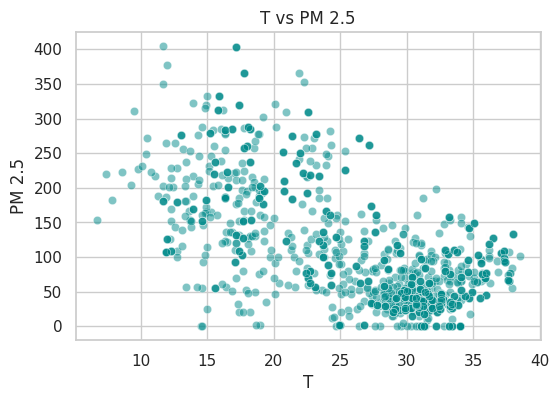

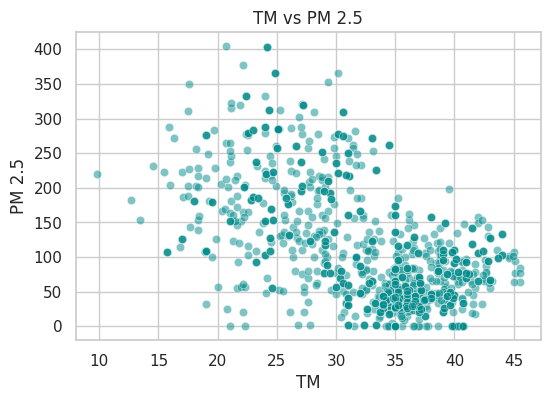

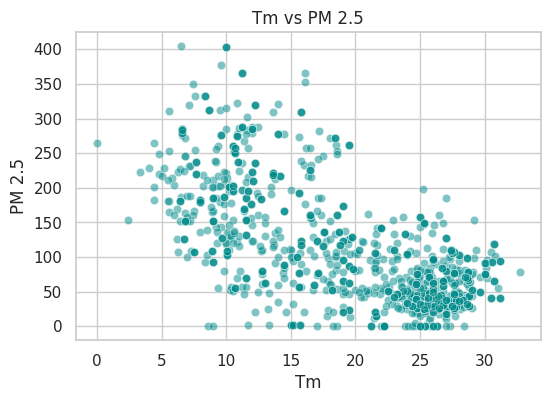

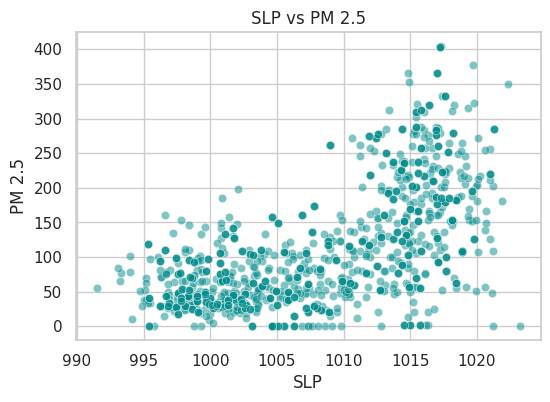

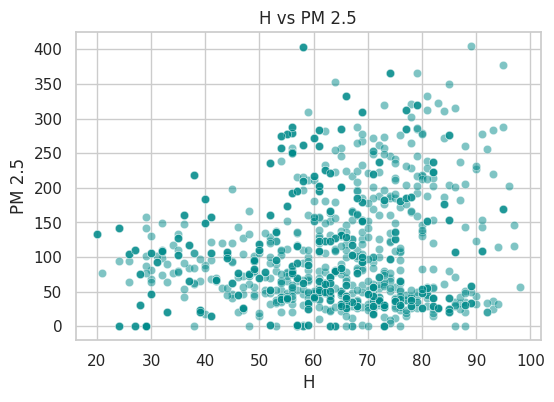

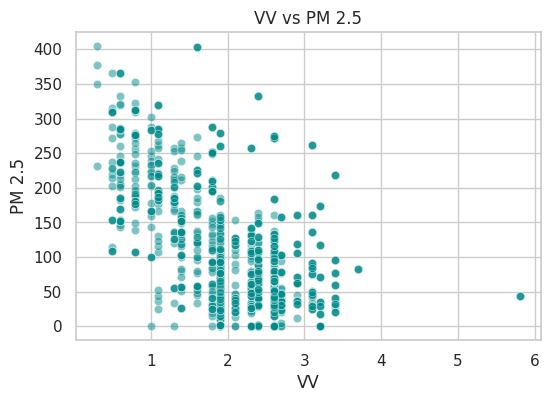

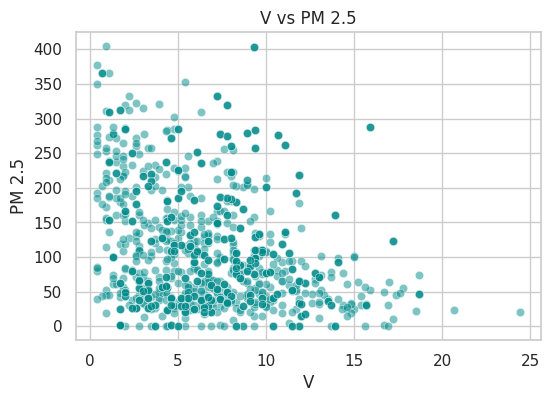

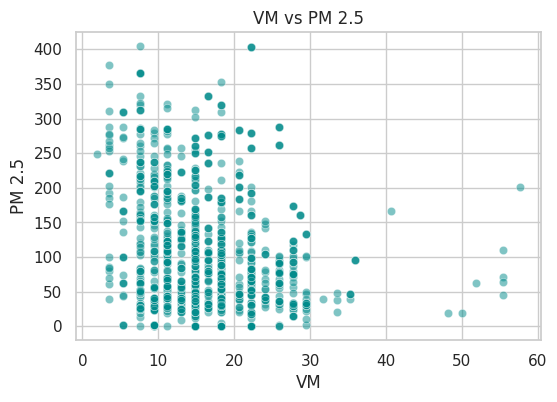

In [ ]:
# Get all the feature columns (everything except 'PM 2.5')
features = data.drop('PM 2.5', axis=1).columns

# Loop through each feature and create a scatter plot
for feature in features:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=data[feature], y=data['PM 2.5'], alpha=0.5, color='darkcyan')
    plt.title(f'{feature} vs PM 2.5')
    plt.xlabel(feature)
    plt.ylabel('PM 2.5')
    plt.show()

In [ ]:
#making dependent and independent variable
x=data.iloc[:,0:8]#independent variable
y=data.iloc[:,8]

In [ ]:
data[(data["PM 2.5"]>108) & (data["PM 2.5"] < 110)]

,T,TM,Tm,SLP,H,VV,V,VM,PM 2.5
23,18.3,23.2,12.7,1011.2,75.0,1.9,10.0,22.2,109.333333
226,22.4,32.5,14.5,1007.2,68.0,2.1,5.4,11.1,109.458333
228,25.2,32.7,19.1,1010.7,64.0,1.9,2.8,11.1,108.208333
249,31.8,38.6,24.2,1004.3,54.0,1.9,1.9,7.6,108.333333
412,28.6,36.5,20.3,1012.4,59.0,1.8,9.3,55.4,109.750000
574,17.4,24.4,10.1,1018.9,61.0,2.3,6.1,11.1,109.333333
605,33.6,40.0,23.0,1003.8,27.0,2.4,9.8,18.3,109.625000
755,17.4,24.4,10.1,1018.9,61.0,2.3,6.1,11.1,109.333333
786,33.6,40.0,23.0,1003.8,27.0,2.4,9.8,18.3,109.625000
936,17.4,24.4,10.1,1018.9,61.0,2.3,6.1,11.1,109.333333


In [ ]:
#train_test_split
x_train , x_test , y_train , y_test=train_test_split(x , y , test_size=0.2 , random_state=0)
print(x_test , x_train , y_test , y_train)

         T    TM    Tm     SLP     H   VV     V    VM
784   31.6  38.0  23.2  1002.6  30.0  3.1  18.7  35.2
741   11.9  15.7   7.5  1018.9  86.0  0.8   6.1  11.1
747   15.9  22.4   8.4  1017.6  66.0  2.4   7.2  16.5
986   32.9  39.0  27.4   996.6  50.0  2.4   9.4  27.8
479   31.6  35.5  25.4  1001.9  63.0  1.9   5.4  11.1
...    ...   ...   ...     ...   ...  ...   ...   ...
655   31.9  35.0  28.3  1001.3  72.0  2.1   2.8   9.4
1087  16.3  23.0   6.6  1016.9  61.0  1.0   9.4  20.6
869   30.3  35.0  24.7  1007.3  62.0  2.3   7.6  18.3
665   29.9  34.0  25.5  1000.2  80.0  1.4   3.3  11.1
674   27.8  31.0  25.2  1001.3  88.0  2.4   4.6   7.6

[219 rows x 8 columns]          T    TM    Tm     SLP     H   VV     V    VM
863   32.5  37.2  25.3  1003.0  59.0  3.1   1.7   7.6
422   26.4  32.5  20.0  1012.8  68.0  2.6   3.0  11.1
342   23.4  31.2  15.0  1013.4  58.0  1.1   4.1  14.8
188   11.9  20.7   4.4  1017.9  78.0  0.8   1.9   7.6
934   17.2  26.0  11.5  1014.7  65.0  2.3   5.7  14.8
... 

In [ ]:
y_train = np.where(np.isnan(y_train), np.nanmean(y_train), y_train)

In [ ]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# Convert y to NumPy array and make 2D
y_train = np.array(y_train).reshape(-1, 1)
y_test = np.array(y_test).reshape(-1, 1)

# Feature scaler
X_scaler = StandardScaler()
X_train_scaled = X_scaler.fit_transform(x_train)
X_test_scaled = X_scaler.transform(x_test)

# Target scaler
y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train)
y_test_scaled = y_scaler.transform(y_test)

# Check NaNs or Infs
print(np.isnan(X_train_scaled).sum(), np.isnan(y_train_scaled).sum())
print(np.isinf(X_train_scaled).sum(), np.isinf(y_train_scaled).sum())



0 0
0 0


In [ ]:
#building a model

def build_model(hp):
    model=Sequential()
    model.add(Dense(units=hp.Int('units_input', min_value=32 , max_value=256 , step=32),
                     activation=hp.Choice('activation _input',['relu' , 'tanh']),
                     input_dim=X_train_scaled.shape[1]))

    for i in range(hp.Int('num_layers',1,3)):
        model.add(Dense(units=hp.Int(f'units_{i}', min_value=32 , max_value=256 , step=32),
                        activation=hp.Choice(f'activation{i}',['relu' , 'tanh'])))
    model.add(Dense(units=1 , activation='linear'))
    #compiling model
    model.compile(optimizer=Adam(hp.Choice('learning_rate', [1e-3, 1e-4])) , loss='mean_squared_error' ,metrics=['mean_absolute_error'])
    return model

In [ ]:
tuner=RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=10,
    directory='my_dir',
    project_name='air_quality_ann',
    overwrite=True
)
tuner.search(X_train_scaled , y_train_scaled, validation_split=0.1, epochs=50, batch_size=16)

Trial 10 Complete [00h 00m 22s]
val_loss: 0.31227967143058777

Best val_loss So Far: 0.22585678100585938
Total elapsed time: 00h 03m 34s


In [ ]:
best_model = tuner.get_best_models(num_models=1)

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
best_model = best_model[0]


In [ ]:
# Generate predictions on scaled test set
y_pred_scaled = best_model.predict(X_test_scaled)

# Inverse transform predictions to original scale
y_pred = y_scaler.inverse_transform(y_pred_scaled)

# Inverse transform actual values to original scale
y_true = y_scaler.inverse_transform(y_test_scaled)

print("Predictions and actual values have been inverse transformed.")
print(f"Sample predicted value: {y_pred[0][0]:.2f}")
print(f"Sample actual value: {y_true[0][0]:.2f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Predictions and actual values have been inverse transformed.
Sample predicted value: 42.73
Sample actual value: 46.92


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Calculate metrics
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)

# Display results
print(f'Regression Metrics on Test Set:')
print(f'Mean Squared Error (MSE): {mse:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')
print(f'R-squared (R2): {r2:.4f}')

Regression Metrics on Test Set:
Mean Squared Error (MSE): 1657.00
Root Mean Squared Error (RMSE): 40.71
R-squared (R2): 0.7654


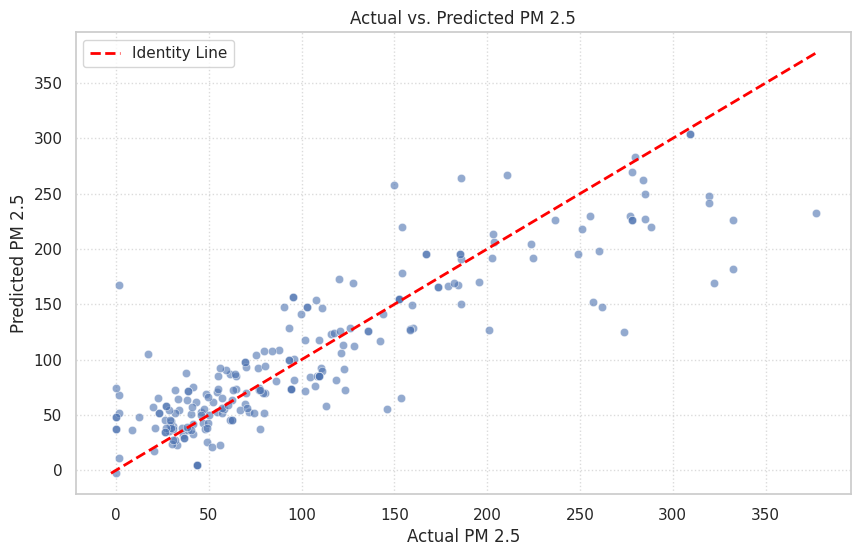

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_true.flatten(), y=y_pred.flatten(), alpha=0.6)

# Determine range for reference line
min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())

# Plot diagonal reference line
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', lw=2, label='Identity Line')

plt.title('Actual vs. Predicted PM 2.5')
plt.xlabel('Actual PM 2.5')
plt.ylabel('Predicted PM 2.5')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

In [ ]:
# ---------------------------
# Take user input and predict
# ---------------------------
print("Enter air quality features to predict PM2.5:")
user_input = []
for col in data.drop("PM 2.5", axis=1).columns:
    value = float(input(f"{col}: "))
    user_input.append(value)

# Convert to numpy array and scale
user_input = np.array(user_input).reshape(1, -1)
user_input_scaled = X_scaler.transform(user_input)

# Make prediction
predicted_pm25_scaled = best_model.predict(user_input_scaled)
predicted_pm25 = y_scaler.inverse_transform(predicted_pm25_scaled)
print(f"Predicted PM2.5 value: {predicted_pm25[0][0]:.2f}")

Enter air quality features to predict PM2.5:
T: 24.5
TM: 29
Tm: 19.5
SLP: 1010.5
H: 75
VV: 3.5
V: 5.0
VM: 8.0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
Predicted PM2.5 value: 24.90


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
